In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import product, permutations

np.random.seed(42)

In [ ]:
def forward_scaled(A, B, pi, obs):
    N = A.shape[0]; T = len(obs)
    alpha = np.zeros((T, N)); c = np.zeros(T)
    alpha[0] = pi * B[:, obs[0]]
    c[0] = alpha[0].sum(); alpha[0] /= c[0]
    for t in range(1, T):
        alpha[t] = (alpha[t-1] @ A) * B[:, obs[t]]
        c[t] = alpha[t].sum(); alpha[t] /= c[t]
    log_prob = np.sum(np.log(c + 1e-300))
    return alpha, c, log_prob

def backward_scaled(A, B, obs, c):
    N = A.shape[0]; T = len(obs)
    beta = np.zeros((T, N))
    beta[T-1] = 1.0 / c[T-1]
    for t in range(T-2, -1, -1):
        beta[t] = A @ (B[:, obs[t+1]] * beta[t+1])
        beta[t] /= c[t]
    return beta

def compute_gamma_xi(A, B, obs, alpha, beta):
    T, N = alpha.shape
    gamma = alpha * beta
    gamma /= gamma.sum(axis=1, keepdims=True)
    xi = np.zeros((T-1, N, N))
    for t in range(T-1):
        numer = (alpha[t][:, None] * A
                 * B[:, obs[t+1]][None, :] * beta[t+1][None, :])
        xi[t] = numer / numer.sum()
    return gamma, xi

def m_step(gamma_list, xi_list, obs_list, N, M):
    eps = 1e-10
    pi_new = np.mean([g[0] for g in gamma_list], axis=0)
    pi_new = np.maximum(pi_new, eps); pi_new /= pi_new.sum()
    numer_A = sum(xi.sum(axis=0) for xi in xi_list)
    denom_A = sum(g[:-1].sum(axis=0) for g in gamma_list)
    A_new = (numer_A + eps) / (denom_A[:, None] + N * eps)
    A_new /= A_new.sum(axis=1, keepdims=True)
    numer_B = np.zeros((N, M)) + eps; denom_B = np.zeros(N) + M * eps
    for g, obs in zip(gamma_list, obs_list):
        for v in range(M):
            mask = (np.array(obs) == v)
            numer_B[:, v] += g[mask].sum(axis=0)
        denom_B += g.sum(axis=0)
    B_new = numer_B / denom_B[:, None]
    B_new /= B_new.sum(axis=1, keepdims=True)
    return A_new, B_new, pi_new

def baum_welch(obs_list, N, M, A_init, B_init, pi_init, max_iter=200, tol=1e-6):
    A = A_init.copy(); B = B_init.copy(); pi = pi_init.copy()
    log_likelihoods = []
    for iteration in range(max_iter):
        gamma_list, xi_list, total_ll = [], [], 0.0
        for obs in obs_list:
            alpha, c, ll = forward_scaled(A, B, pi, obs)
            beta          = backward_scaled(A, B, obs, c)
            gamma, xi     = compute_gamma_xi(A, B, obs, alpha, beta)
            gamma_list.append(gamma); xi_list.append(xi); total_ll += ll
        log_likelihoods.append(total_ll)
        if len(log_likelihoods) > 1:
            delta = log_likelihoods[-1] - log_likelihoods[-2]
            if abs(delta) < tol:
                print(f'  Converged at iteration {iteration+1}  (delta_ll = {delta:.2e})')
                break
        A, B, pi = m_step(gamma_list, xi_list, obs_list, N, M)
    return A, B, pi, log_likelihoods

def generate_hmm_sequences(A, B, pi, T, n_seqs, seed=0):
    rng = np.random.default_rng(seed)
    N = A.shape[0]; M = B.shape[1]
    obs_list, state_list = [], []
    for _ in range(n_seqs):
        states, obs = [], []
        s = rng.choice(N, p=pi)
        for _ in range(T):
            states.append(s)
            obs.append(rng.choice(M, p=B[s]))
            s = rng.choice(N, p=A[s])
        obs_list.append(obs); state_list.append(states)
    return obs_list, state_list

def random_hmm_init(N, M, seed):
    rng = np.random.default_rng(seed)
    A  = rng.dirichlet(np.ones(N), size=N)
    B  = rng.dirichlet(np.ones(M), size=N)
    pi = rng.dirichlet(np.ones(N))
    return A, B, pi

def best_permutation_mae(A_true, B_true, pi_true, A_hat, B_hat, pi_hat):
    N = A_true.shape[0]; best_mae, best_perm = np.inf, None
    for perm in permutations(range(N)):
        p = list(perm)
        mae = (np.abs(A_true - A_hat[p][:, p]).mean()
             + np.abs(B_true - B_hat[p]).mean()
             + np.abs(pi_true - pi_hat[p]).mean()) / 3
        if mae < best_mae: best_mae, best_perm = mae, p
    return best_mae, best_perm



In [ ]:
A_true  = np.array([[0.7, 0.3], [0.4, 0.6]])
B_true  = np.array([[0.9, 0.1], [0.2, 0.8]])
pi_true = np.array([0.6, 0.4])
N_TRUE, M_TRUE = 2, 2

obs_train, _ = generate_hmm_sequences(A_true, B_true, pi_true, T=50, n_seqs=20, seed=7)
print(f'Training: {len(obs_train)} sequences, length {len(obs_train[0])}')

Training: 20 sequences, length 50


## experiment 1: log-likelihood convergence

Monotonic increase : True
Iterations         : 300
LL: -697.7289 -> -667.7011


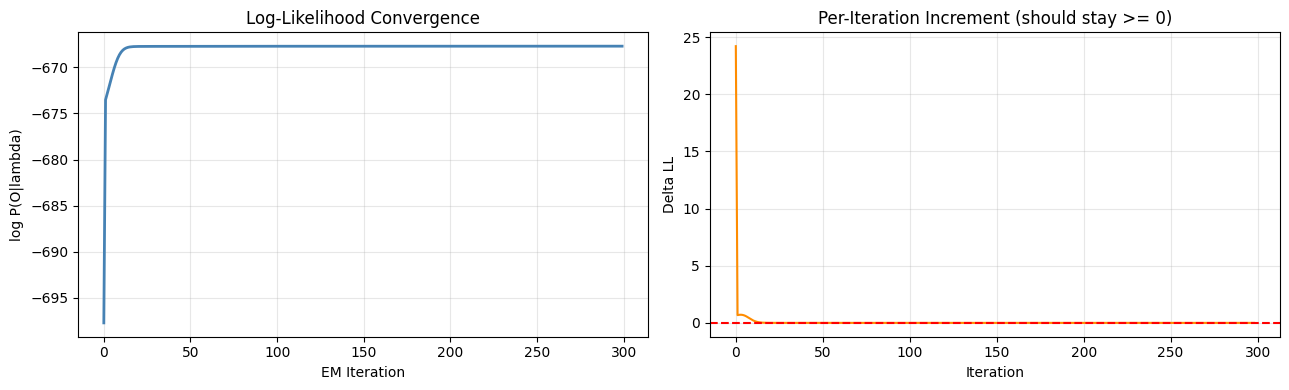

In [ ]:
A0, B0, pi0 = random_hmm_init(N_TRUE, M_TRUE, seed=99)
A_learned, B_learned, pi_learned, lls = baum_welch(
    obs_train, N_TRUE, M_TRUE, A0, B0, pi0, max_iter=300, tol=1e-8)

diffs = np.diff(lls)
print(f'Monotonic increase : {np.all(diffs >= -1e-6)}')
print(f'Iterations         : {len(lls)}')
print(f'LL: {lls[0]:.4f} -> {lls[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(lls, color='steelblue', linewidth=2)
axes[0].set_xlabel('EM Iteration'); axes[0].set_ylabel('log P(O|lambda)')
axes[0].set_title('Log-Likelihood Convergence'); axes[0].grid(True, alpha=0.3)
axes[1].plot(np.maximum(diffs, -0.01), color='darkorange', linewidth=1.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Delta LL')
axes[1].set_title('Per-Iteration Increment (should stay >= 0)'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('bw_convergence.png', dpi=150); plt.show()

Permutation: [1, 0],  Overall MAE: 0.115216
A MAE : 0.061424
B MAE : 0.062203
pi MAE: 0.222020

True A:
[[0.7 0.3]
 [0.4 0.6]]
Learned A:
[[0.78   0.22  ]
 [0.3572 0.6428]]

True B:
[[0.9 0.1]
 [0.2 0.8]]
Learned B:
[[0.8085 0.1915]
 [0.2329 0.7671]]

True pi: [0.6 0.4]
Learned pi: [0.378 0.622]


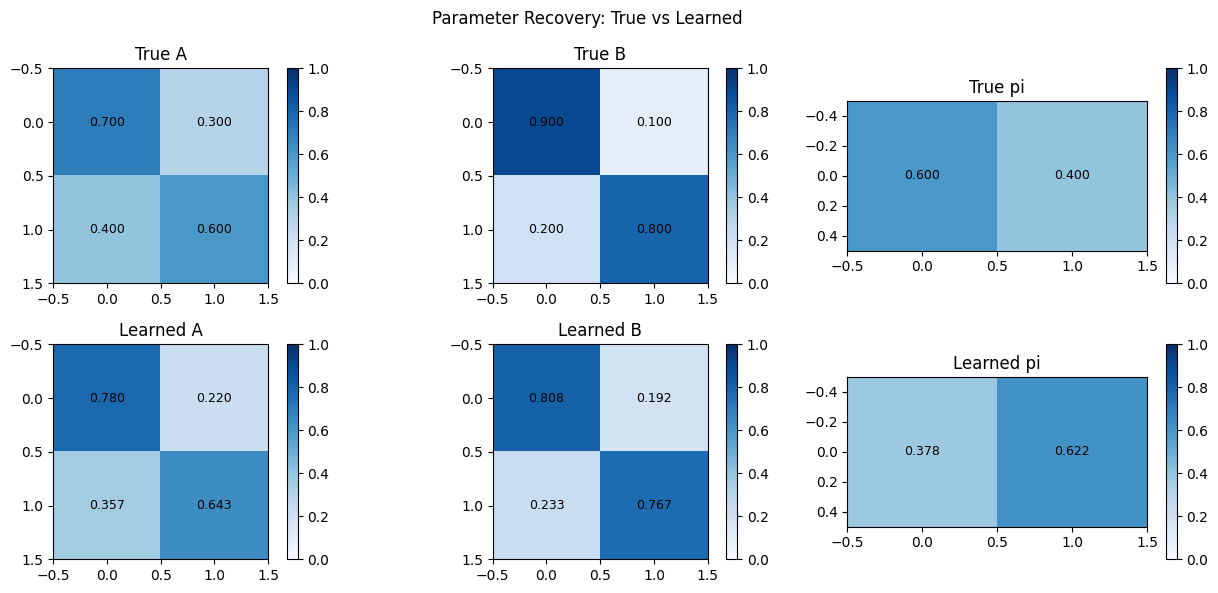

In [ ]:
#Experiment 2
mae, perm = best_permutation_mae(A_true, B_true, pi_true, A_learned, B_learned, pi_learned)
p = perm
A_aligned = A_learned[p][:, p]; B_aligned = B_learned[p]; pi_aligned = pi_learned[p]

print(f'Permutation: {perm},  Overall MAE: {mae:.6f}')
print(f'A MAE : {np.abs(A_true - A_aligned).mean():.6f}')
print(f'B MAE : {np.abs(B_true - B_aligned).mean():.6f}')
print(f'pi MAE: {np.abs(pi_true - pi_aligned).mean():.6f}')
print(f'\nTrue A:\n{A_true}\nLearned A:\n{A_aligned.round(4)}')
print(f'\nTrue B:\n{B_true}\nLearned B:\n{B_aligned.round(4)}')
print(f'\nTrue pi: {pi_true}\nLearned pi: {pi_aligned.round(4)}')

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
mats_true = [A_true, B_true, pi_true.reshape(1,-1)]
mats_lrnd = [A_aligned, B_aligned, pi_aligned.reshape(1,-1)]
titles_t  = ['True A','True B','True pi']
titles_l  = ['Learned A','Learned B','Learned pi']
for col in range(3):
    for row, (mat, title) in enumerate([(mats_true[col], titles_t[col]),
                                         (mats_lrnd[col], titles_l[col])]):
        im = axes[row,col].imshow(mat, vmin=0, vmax=1, cmap='Blues')
        axes[row,col].set_title(title)
        for r in range(mat.shape[0]):
            for c2 in range(mat.shape[1]):
                axes[row,col].text(c2, r, f'{mat[r,c2]:.3f}', ha='center', va='center', fontsize=9)
        plt.colorbar(im, ax=axes[row,col])
plt.suptitle('Parameter Recovery: True vs Learned'); plt.tight_layout()
plt.savefig('param_recovery.png', dpi=150); plt.show()

##Experiment 3

Run  1: LL=-678.618  iters=300  MAE=0.285771
Run  2: LL=-667.886  iters=300  MAE=0.147516
Run  3: LL=-667.714  iters=300  MAE=0.097608
Run  4: LL=-667.759  iters=300  MAE=0.138438
Run  5: LL=-678.562  iters=300  MAE=0.346122
Run  6: LL=-678.595  iters=300  MAE=0.376339
Run  7: LL=-667.700  iters=300  MAE=0.109309
Run  8: LL=-667.703  iters=300  MAE=0.104226
Run  9: LL=-667.731  iters=300  MAE=0.131618
Run 10: LL=-667.778  iters=300  MAE=0.141636

Best run: 7,  LL=-667.7004,  Std=4.9670


/tmp/ipykernel_6295/1989853628.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 10)


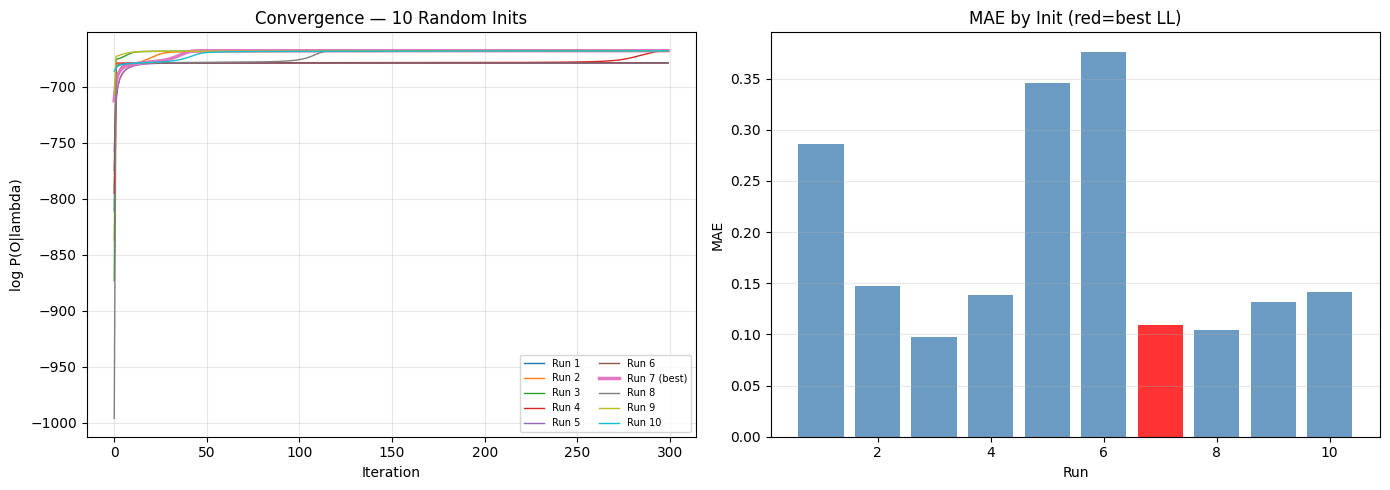

In [ ]:
results = []
for run in range(10):
    A0r, B0r, pi0r = random_hmm_init(N_TRUE, M_TRUE, seed=run*13)
    A_r, B_r, pi_r, lls_r = baum_welch(obs_train, N_TRUE, M_TRUE, A0r, B0r, pi0r, max_iter=300)
    mae_r, _ = best_permutation_mae(A_true, B_true, pi_true, A_r, B_r, pi_r)
    results.append({'run':run+1,'final_ll':lls_r[-1],'iters':len(lls_r),'mae':mae_r,'lls':lls_r})
    print(f"Run {run+1:2d}: LL={lls_r[-1]:8.3f}  iters={len(lls_r)}  MAE={mae_r:.6f}")

final_lls = [r['final_ll'] for r in results]
best_run_idx = int(np.argmax(final_lls))
print(f'\nBest run: {best_run_idx+1},  LL={max(final_lls):.4f},  Std={np.std(final_lls):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap = plt.cm.get_cmap('tab10', 10)
for i, r in enumerate(results):
    axes[0].plot(r['lls'], color=cmap(i), linewidth=2.5 if i==best_run_idx else 1.0,
                 label=f"Run {r['run']}" + (' (best)' if i==best_run_idx else ''))
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('log P(O|lambda)')
axes[0].set_title('Convergence — 10 Random Inits'); axes[0].legend(fontsize=7, ncol=2); axes[0].grid(True, alpha=0.3)
colors = ['red' if i==best_run_idx else 'steelblue' for i in range(10)]
axes[1].bar([r['run'] for r in results], [r['mae'] for r in results], color=colors, alpha=0.8)
axes[1].set_xlabel('Run'); axes[1].set_ylabel('MAE'); axes[1].set_title('MAE by Init (red=best LL)'); axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig('multi_init.png', dpi=150); plt.show()

##Experiment 4

     T |        MAE |    Iters
    10 |   0.131987 |      300
    20 |   0.118433 |      300
    50 |   0.102667 |      300
   100 |   0.131640 |      300
   200 |   0.071979 |      300
   500 |   0.041089 |      300

   N |     Final LL |    Iters
   2 |   -2188.3974 |      300
   3 |   -1902.2646 |      300
   4 |   -2146.5558 |      300
   5 |   -2166.5623 |      300


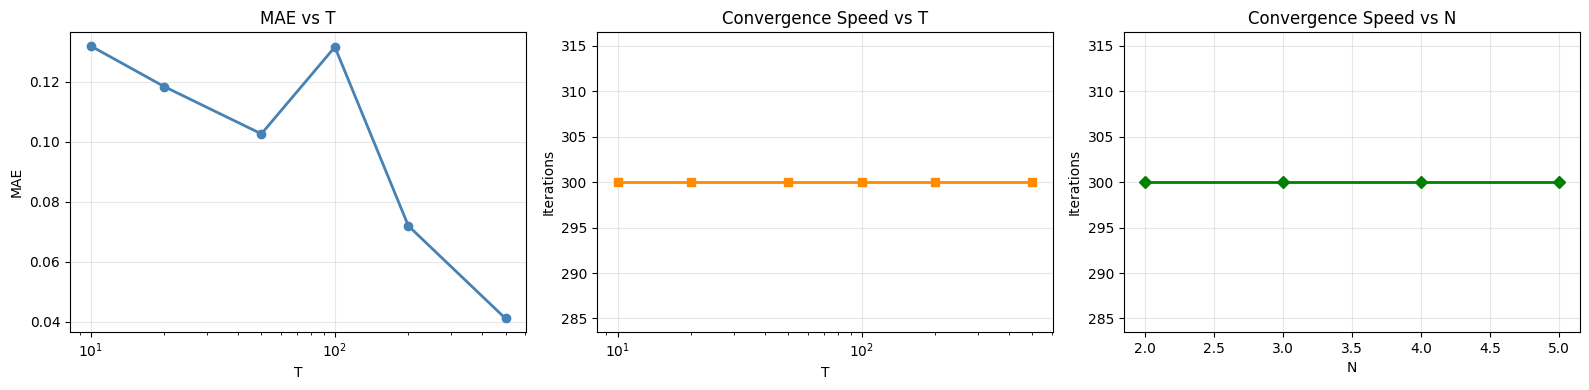

In [ ]:
# 4A: vary T
T_values = [10, 20, 50, 100, 200, 500]
mae_by_T, iters_by_T = [], []
print(f"{'T':>6} | {'MAE':>10} | {'Iters':>8}")
for T_val in T_values:
    obs_t, _ = generate_hmm_sequences(A_true, B_true, pi_true, T=T_val, n_seqs=20, seed=42)
    A0t, B0t, pi0t = random_hmm_init(N_TRUE, M_TRUE, seed=best_run_idx*13)
    A_t, B_t, pi_t, lls_t = baum_welch(obs_t, N_TRUE, M_TRUE, A0t, B0t, pi0t, max_iter=300)
    mae_t, _ = best_permutation_mae(A_true, B_true, pi_true, A_t, B_t, pi_t)
    mae_by_T.append(mae_t); iters_by_T.append(len(lls_t))
    print(f'{T_val:>6} | {mae_t:>10.6f} | {len(lls_t):>8}')

# 4B: vary N
N_values = [2, 3, 4, 5]
iters_by_N, ll_by_N = [], []
print(f"\n{'N':>4} | {'Final LL':>12} | {'Iters':>8}")
for N_val in N_values:
    A_n, B_n, pi_n = random_hmm_init(N_val, 3, seed=N_val*7)
    obs_n, _ = generate_hmm_sequences(A_n, B_n, pi_n, T=100, n_seqs=20, seed=N_val)
    A0n, B0n, pi0n = random_hmm_init(N_val, 3, seed=0)
    _, _, _, lls_n = baum_welch(obs_n, N_val, 3, A0n, B0n, pi0n, max_iter=300)
    iters_by_N.append(len(lls_n)); ll_by_N.append(lls_n[-1])
    print(f'{N_val:>4} | {lls_n[-1]:>12.4f} | {len(lls_n):>8}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(T_values, mae_by_T, 'o-', color='steelblue', linewidth=2)
axes[0].set_xscale('log'); axes[0].set_xlabel('T'); axes[0].set_ylabel('MAE')
axes[0].set_title('MAE vs T'); axes[0].grid(True, alpha=0.3)
axes[1].plot(T_values, iters_by_T, 's-', color='darkorange', linewidth=2)
axes[1].set_xscale('log'); axes[1].set_xlabel('T'); axes[1].set_ylabel('Iterations')
axes[1].set_title('Convergence Speed vs T'); axes[1].grid(True, alpha=0.3)
axes[2].plot(N_values, iters_by_N, 'D-', color='green', linewidth=2)
axes[2].set_xlabel('N'); axes[2].set_ylabel('Iterations')
axes[2].set_title('Convergence Speed vs N'); axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('sensitivity.png', dpi=150); plt.show()

In [ ]:
print('Exp 1 — LL monotonic increase : VERIFIED')
print(f'Exp 2 — Parameter recovery MAE: {mae:.6f}')
print(f'Exp 3 — Best run (of 10)      : Run {best_run_idx+1}')
print(f'Exp 4A — MAE at T=500         : {mae_by_T[-1]:.6f}')
print(f'Exp 4B — Iters for N=5        : {iters_by_N[-1]}')
print('\n Baum-Welch: ALL EXPERIMENTS COMPLETE')

Exp 1 — LL monotonic increase : VERIFIED
Exp 2 — Parameter recovery MAE: 0.115216
Exp 3 — Best run (of 10)      : Run 7
Exp 4A — MAE at T=500         : 0.041089
Exp 4B — Iters for N=5        : 300

 Baum-Welch: ALL EXPERIMENTS COMPLETE
